In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv("./air_quality.csv")

In [6]:
df.head(5)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [7]:
df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [9]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [10]:
df.shape

(29531, 16)

## Handling Missing Values

In [11]:
# dropping where AQI is NA because AQI is key param
df = df.dropna(subset=['AQI'])

In [12]:
# other missing values
df.fillna(method = 'ffill' , inplace = True)

/tmp/ipykernel_20315/631688690.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method = 'ffill' , inplace = True)


In [13]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,0
PM10,932
NO,0
NO2,0
NOx,0
NH3,1334
CO,0
SO2,0


In [14]:
df.shape

(24850, 16)

### Data Processing

In [15]:
# Date Column
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [16]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
10229,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe
10230,Delhi,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,4.29,454.0,Severe
10231,Delhi,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,1.99,143.0,Moderate
10232,Delhi,2015-01-04,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,3.34,319.0,Very Poor
10233,Delhi,2015-01-05,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,2.96,325.0,Very Poor


In [17]:
# only delhi data
df = df[df['City'] =='Delhi']

In [18]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
10229,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe
10230,Delhi,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,4.29,454.0,Severe
10231,Delhi,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,1.99,143.0,Moderate
10232,Delhi,2015-01-04,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,3.34,319.0,Very Poor
10233,Delhi,2015-01-05,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,2.96,325.0,Very Poor


In [19]:
df['City']

,City
10229,Delhi
10230,Delhi
10231,Delhi
10232,Delhi
10233,Delhi
...,...
12233,Delhi
12234,Delhi
12235,Delhi
12236,Delhi


In [20]:
df.shape

(1999, 16)

In [21]:
df.reset_index(drop = True , inplace = True)

In [22]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe
1,Delhi,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,4.29,454.0,Severe
2,Delhi,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,1.99,143.0,Moderate
3,Delhi,2015-01-04,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,3.34,319.0,Very Poor
4,Delhi,2015-01-05,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,2.96,325.0,Very Poor


In [23]:
df.shape

(1999, 16)

In [24]:
df['AQI_Next'] = df['AQI'].shift(-1)

In [25]:
df.tail()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,AQI_Next
1994,Delhi,2020-06-27,39.80,155.94,10.88,21.46,22.47,31.43,0.87,10.38,18.88,1.69,19.99,0.43,112.0,Moderate,196.0
1995,Delhi,2020-06-28,59.52,308.65,12.67,21.60,23.86,29.27,0.94,10.70,18.05,1.71,25.13,1.74,196.0,Moderate,233.0
1996,Delhi,2020-06-29,44.86,184.12,10.50,21.57,21.94,27.97,0.88,11.58,26.61,2.13,23.80,1.13,233.0,Poor,114.0
1997,Delhi,2020-06-30,39.80,91.98,5.99,17.96,15.44,28.48,0.84,10.51,37.29,1.57,16.37,0.49,114.0,Moderate,101.0
1998,Delhi,2020-07-01,54.01,128.66,6.33,21.05,16.81,29.06,0.97,11.15,29.73,2.03,23.57,0.65,101.0,Moderate,NaN


In [26]:
df.dropna(inplace=True)

In [27]:
df.shape

(1998, 17)

In [28]:
df[['AQI','AQI_Next']].head()

,AQI,AQI_Next
0,472.0,454.0
1,454.0,143.0
2,143.0,319.0
3,319.0,325.0
4,325.0,318.0


In [29]:
df = df.drop(columns = 'City')

In [30]:
df.head()

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,AQI_Next
0,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe,454.0
1,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,4.29,454.0,Severe,143.0
2,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,1.99,143.0,Moderate,319.0
3,2015-01-04,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,3.34,319.0,Very Poor,325.0
4,2015-01-05,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,2.96,325.0,Very Poor,318.0


### EDA

In [31]:
features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'O3']

In [32]:
x = df[features]
y = df['AQI_Next']

In [33]:
x.head()

,PM2.5,PM10,NO,NO2,NOx,CO,SO2,O3
0,313.22,607.98,69.16,36.39,110.59,15.20,9.25,41.68
1,186.18,269.55,62.09,32.87,88.14,9.54,6.65,29.97
2,87.18,131.90,25.73,30.31,47.95,10.61,2.65,19.71
3,151.84,241.84,25.01,36.91,48.62,11.54,4.63,25.36
4,146.60,219.13,14.01,34.92,38.25,9.20,3.33,23.20


In [34]:
y.head()

,AQI_Next
0,454.0
1,143.0
2,319.0
3,325.0
4,318.0


### Model Training

In [35]:
pip install scikit-learn

#### Train test split model

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
import sklearn
print(sklearn.__version__)

1.6.1


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, shuffle=False
)

In [39]:
print(X_train.shape, X_test.shape)

(1598, 8) (400, 8)


#### Random Forest Model

In [40]:
from sklearn.ensemble import RandomForestRegressor

In [61]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [62]:
accuracy = rf_model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.8928801387912235


#### Predictions

In [63]:
y_pred = rf_model.predict(X_test)

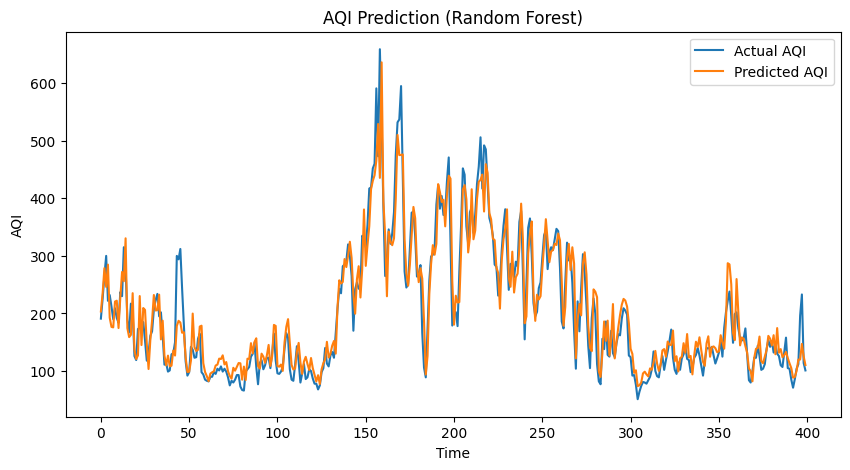

In [64]:
# AQI Prediction graph (random forest)
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label='Actual AQI')
plt.plot(y_pred, label='Predicted AQI')

plt.legend()
plt.title("AQI Prediction (Random Forest)")
plt.xlabel("Time")
plt.ylabel("AQI")

plt.show()

### Evaluation Metrics

In [45]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 37.205917093252786
MAE: 27.088175


## Deep Learning (LTSM)

In [46]:
pip install tensorflow

In [47]:
import tensorflow as tf
print(tf.__version__)

2.19.0


### Data Preparation

In [48]:
from sklearn.preprocessing import MinMaxScaler

In [49]:
data = df[['AQI']].values

In [50]:
# scale data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [51]:
print(data_scaled[:5])

[[0.64483261]
 [0.61863173]
 [0.16593886]
 [0.42212518]
 [0.43085881]]


### Sequence Creation

In [53]:
X = []
y = []

# use past 10 days to predict next day
for i in range(10, len(data_scaled)):
    X.append(data_scaled[i-10:i])
    y.append(data_scaled[i])

X = np.array(X)
y = np.array(y)

In [54]:
print(X.shape)
print(y.shape)

(1988, 10, 1)
(1988, 1)


## LTSM Model Building

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(50, return_sequences=False, input_shape=(10,1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [56]:
model.fit(X, y, epochs=5, batch_size=32)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0339
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0108
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0103
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0098
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0094


### Prediction

In [57]:
predicted = model.predict(X)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [58]:
predicted = scaler.inverse_transform(predicted)
actual = scaler.inverse_transform(y)

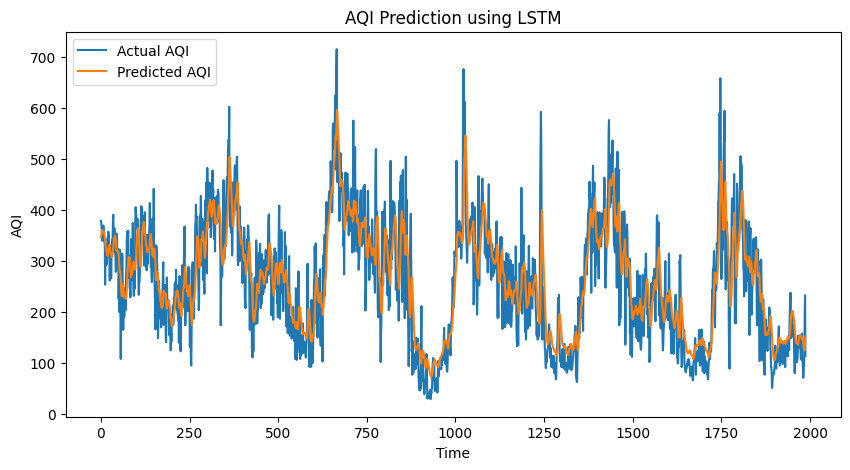

In [59]:
# AQI Prediction (LTSM)
plt.figure(figsize=(10,5))

plt.plot(actual, label='Actual AQI')
plt.plot(predicted, label='Predicted AQI')

plt.legend()
plt.title("AQI Prediction using LSTM")

plt.xlabel("Time")
plt.ylabel("AQI")

plt.show()

In [65]:
latest_data = df[features].iloc[-1:]
prediction = rf_model.predict(latest_data)

print("Tomorrow AQI (Auto Prediction):", prediction[0])

Tomorrow AQI (Auto Prediction): 110.39


In [66]:
last_10_days = data_scaled[-10:]
last_10_days = last_10_days.reshape(1,10,1)

pred = model.predict(last_10_days)
pred = scaler.inverse_transform(pred)

print("Next Day AQI (LSTM):", pred[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Next Day AQI (LSTM): 152.82658


In [69]:
# Example input (you can change values manually)
sample = np.array([[86, 151, 9, 64, 37, 0.97, 15, 55]])

prediction = rf_model.predict(sample)

print("Predicted AQI:", prediction[0])

Predicted AQI: 220.01


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


### Live Data Fetching

In [70]:
def get_live_data():
    latest = df[features].iloc[-1:]
    return latest

In [71]:
live_data = get_live_data()
print(live_data)

      PM2.5   PM10    NO    NO2    NOx    CO    SO2     O3
1997   39.8  91.98  5.99  17.96  15.44  0.84  10.51  37.29


In [72]:
def predict_aqi():
    live_data = get_live_data()
    prediction = rf_model.predict(live_data)

    print("Live Input Data:\n", live_data)
    print("\nPredicted AQI for Tomorrow:", prediction[0])

In [73]:
predict_aqi()

Live Input Data:
       PM2.5   PM10    NO    NO2    NOx    CO    SO2     O3
1997   39.8  91.98  5.99  17.96  15.44  0.84  10.51  37.29

Predicted AQI for Tomorrow: 110.39


## Dashboard using Streamlit

In [74]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 119.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 129.3 MB/s eta 0:00:00
